In [1]:
import numpy as np
import gudhi as gd
import pandas as pd
from sklearn import manifold
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.tri as mtri
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

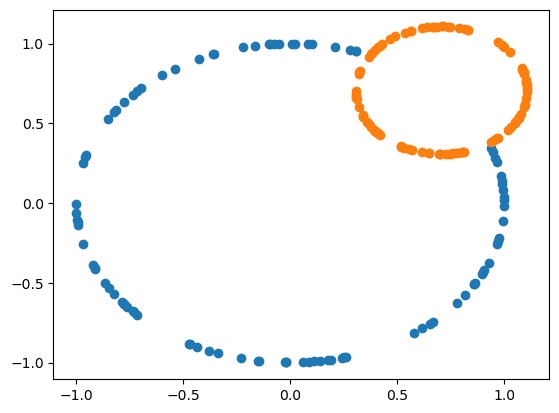

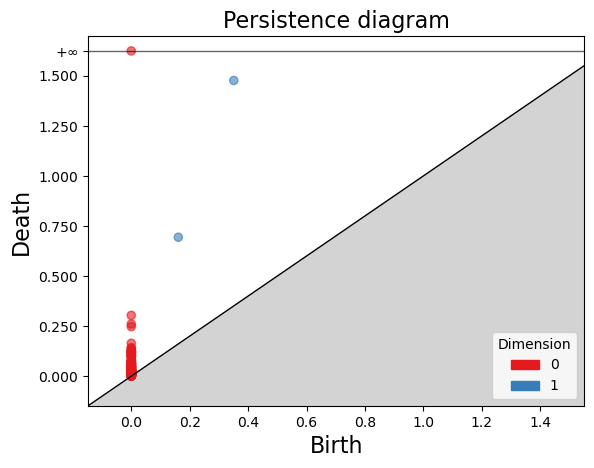

In [5]:

n_points = 100
R = 1
r = 0.4

# Big circle
theta = np.random.uniform(0, 2*np.pi, n_points)
x_big = R * np.cos(theta)
y_big = R * np.sin(theta)

# small circle
theta_center = np.pi / 4 
center_x = R * np.cos(theta_center)
center_y = R * np.sin(theta_center)

x_small = center_x + r * np.cos(theta)
y_small = center_y + r * np.sin(theta)

# remove points in small circle
dist_to_small_center = np.sqrt((x_big - center_x)**2 + (y_big - center_y)**2)

mask = dist_to_small_center >= r
x_big_filtered = x_big[mask]
y_big_filtered = y_big[mask]

big_points = np.column_stack((x_big_filtered, y_big_filtered))
small_points = np.column_stack((x_small, y_small))

points1 = np.vstack((big_points, small_points))

plt.scatter(x_big_filtered, y_big_filtered)
plt.scatter(x_small, y_small)

crp = gd.RipsComplex(points=points1)
ct = crp.create_simplex_tree(max_dimension=2)
barcodes_crp=ct.persistence()

gd.plot_persistence_diagram(barcodes_crp)


<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

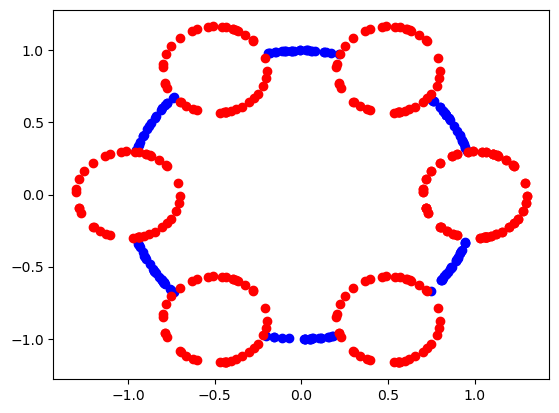

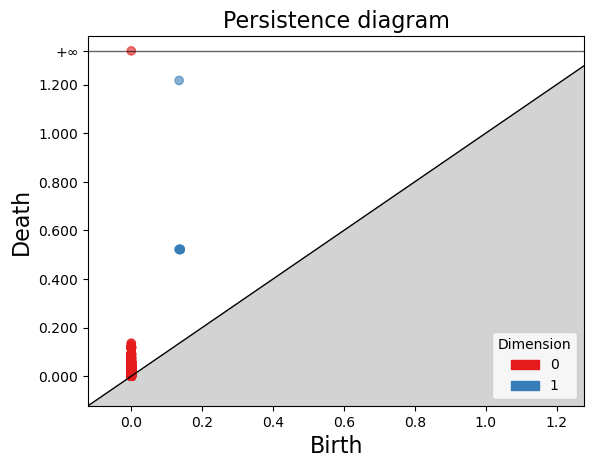

In [4]:

n_points = 300
R = 1
r = 0.3
n_small = 7  # number of small circle

# big circle
theta = np.random.uniform(0, 2*np.pi, n_points)
x_big = R * np.cos(theta)
y_big = R * np.sin(theta)

# not evenly spaced
theta_centers = np.linspace(0, 2*np.pi, n_small)
thetaSmall = np.random.uniform(0, 2*np.pi, int(n_points/n_small))

centers = [(R*np.cos(t), R*np.sin(t)) for t in theta_centers]


mask = np.ones_like(x_big, dtype=bool)


for cx, cy in centers:
    dist = np.sqrt((x_big - cx)**2 + (y_big - cy)**2)
    mask &= dist >= r 

x_big_filtered = x_big[mask]
y_big_filtered = y_big[mask]

big_points = np.column_stack((x_big_filtered, y_big_filtered))



plt.scatter(x_big_filtered, y_big_filtered, color='blue', label="Big Circle")

small_points_list = []

for cx, cy in centers:
    x_small = cx + r*np.cos(thetaSmall)
    y_small = cy + r*np.sin(thetaSmall)
    
    small_points = np.column_stack((x_small, y_small))
    small_points_list.append(small_points)
    plt.scatter(x_small, y_small, color='red')
    
small_points_all = np.vstack(small_points_list)    
points2 = np.vstack((big_points, small_points_all))

srp = gd.RipsComplex(points=points2)
st = srp.create_simplex_tree(max_dimension=2)

barcodes_srp=st.persistence()

st.compute_persistence()

gd.plot_persistence_diagram(barcodes_srp)
    
    

In [ ]:

n_points = 300
R = 1
r = 0.08
n_small = 6   # number of small circle

# big circle
theta = np.random.uniform(0, 2*np.pi, n_points)
x_big = R * np.cos(theta)
y_big = R * np.sin(theta)

# not evenly spaced
theta_centers = np.random.uniform(0, 2*np.pi, n_small)
thetaSmall = np.random.uniform(0, 2*np.pi, int(n_points/2*n_small))

centers = [(R*np.cos(t), R*np.sin(t)) for t in theta_centers]


mask = np.ones_like(x_big, dtype=bool)

for cx, cy in centers:
    dist = np.sqrt((x_big - cx)**2 + (y_big - cy)**2)
    mask &= dist >= r 

x_big_filtered = x_big[mask]
y_big_filtered = y_big[mask]

big_points = np.column_stack((x_big_filtered, y_big_filtered))

plt.figure(figsize=(6,6))

plt.scatter(x_big_filtered, y_big_filtered, color='blue', label="Big Circle")

small_points_list = []

for cx, cy in centers:
    x_small = cx + r*np.cos(thetaSmall)
    y_small = cy + r*np.sin(thetaSmall)
    
    small_points = np.column_stack((x_small, y_small))
    small_points_list.append(small_points)
    plt.scatter(x_small, y_small, color='red')
    
small_points_all = np.vstack(small_points_list)    
points3 = np.vstack((big_points, small_points_all))


ip = gd.RipsComplex(points=points3)
it = ip.create_simplex_tree(max_dimension=2)

barcodes_ip=it.persistence()

it.compute_persistence()

gd.plot_persistence_diagram(barcodes_ip)
